In [1]:
# Import Libraries
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load Dataset
(train_x, train_y), (test_x, test_y) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
# Reshape + Normalize
train_x = train_x.reshape(-1, 28, 28, 1) / 255.0
test_x = test_x.reshape(-1, 28, 28, 1) / 255.0

In [10]:
# Build CNN Model
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [11]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [12]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train Model
history = model.fit(train_x, train_y,
                    epochs=5,
                    validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.8256 - loss: 0.4783 - val_accuracy: 0.8572 - val_loss: 0.3876
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8822 - loss: 0.3231 - val_accuracy: 0.8898 - val_loss: 0.3170
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 59s 30ms/step - accuracy: 0.8998 - loss: 0.2706 - val_accuracy: 0.8885 - val_loss: 0.3014
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.9117 - loss: 0.2386 - val_accuracy: 0.9032 - val_loss: 0.2681
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 78s 27ms/step - accuracy: 0.9233 - loss: 0.2115 - val_accuracy: 0.9065 - val_loss: 0.2602


In [14]:
loss, acc = model.evaluate(test_x, test_y)
print("Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9064 - loss: 0.2636
Accuracy: 0.9064000248908997


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step
Predicted: Dress


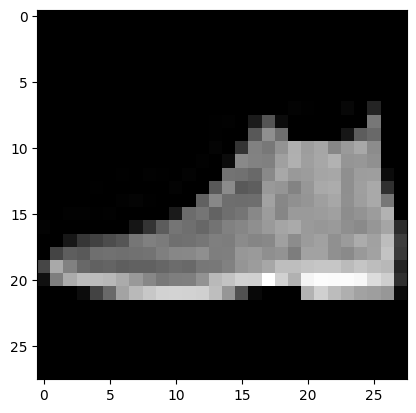

In [15]:
# Prediction Example
labels = ['Trouser', 'Sneaker', 'Ankle Boot', 'T-shirt', 'Coat',
          'Sandal', 'Shirt', 'Bag', 'Pullover', 'Dress'] 

pred = model.predict(test_x[:1])
print("Predicted:", labels[np.argmax(pred)])

plt.imshow(test_x[0].reshape(28,28), cmap='gray')
plt.show()